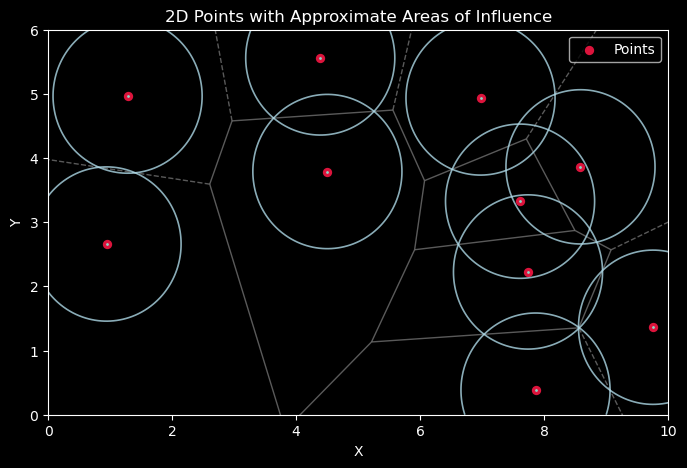

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.spatial import Voronoi, voronoi_plot_2d

# Parameters
n_points = 10
window = ((0, 10), (0, 6))  # rectangular window: x from 0–10, y from 0–6

# Generate random 2D points inside the window
rng = np.random.default_rng(42)
points = np.column_stack((
    rng.uniform(window[0][0], window[0][1], n_points),
    rng.uniform(window[1][0], window[1][1], n_points)
))

# Create Voronoi diagram for visual “area of influence”
vor = Voronoi(points)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 5))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='gray', line_width=1, line_alpha=0.7, point_size=2)

# Plot the points
ax.scatter(points[:, 0], points[:, 1], c='crimson', s=60, edgecolor='k', label="Points")

# Plot Gaussian-like contour blobs for visual area of influence
for x, y in points:
    # Create a Gaussian-like contour centered at (x, y)
    X, Y = np.meshgrid(np.linspace(*window[0], 200), np.linspace(*window[1], 200))
    Z = np.exp(-((X - x)**2 + (Y - y)**2) / 1.2)  # adjust denominator for spread
    ax.contour(X, Y, Z, levels=[0.3], colors='lightblue', linewidths=1.2, alpha=0.8)

# Window bounds
ax.set_xlim(window[0])
ax.set_ylim(window[1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Points with Approximate Areas of Influence")
ax.legend()
plt.show()


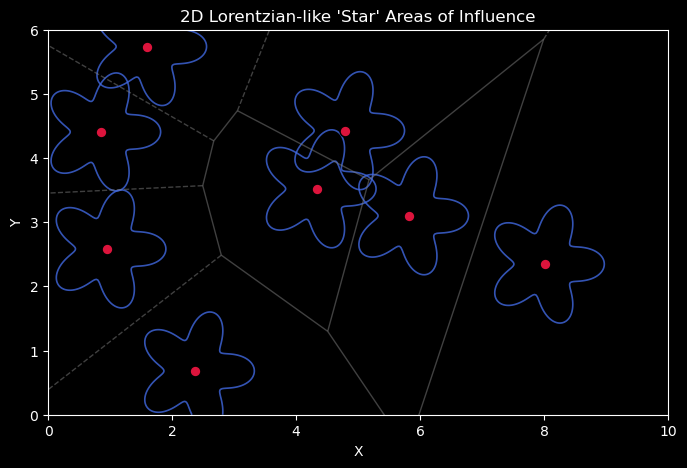

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# Parameters
n_points = 8
window = ((0, 10), (0, 6))
rng = np.random.default_rng(3)

# Generate random points
points = np.column_stack((
    rng.uniform(window[0][0], window[0][1], n_points),
    rng.uniform(window[1][0], window[1][1], n_points)
))

# Define a 2D Lorentzian-like function
def lorentzian_2d(X, Y, x0, y0, gamma=0.6):
    r2 = (X - x0)**2 + (Y - y0)**2
    return 1 / (1 + (r2 / gamma**2))

# Optional: add angular modulation → "star-like" shape
def lorentzian_star(X, Y, x0, y0, gamma=0.6, n_arms=6, strength=0.3):
    angle = np.arctan2(Y - y0, X - x0)
    mod = 1 + strength * np.cos(n_arms * angle)
    r2 = ((X - x0)**2 + (Y - y0)**2)
    return mod / (1 + (r2 / gamma**2))

# Create plotting grid
x = np.linspace(*window[0], 400)
y = np.linspace(*window[1], 400)
X, Y = np.meshgrid(x, y)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(points[:, 0], points[:, 1], color='crimson', s=60, edgecolor='k', zorder=3)

# Plot Lorentzian/star contours
for (x0, y0) in points:
    Z = lorentzian_star(X, Y, x0, y0, gamma=0.5, n_arms=5, strength=0.4)
    ax.contour(X, Y, Z, levels=[0.3], colors='royalblue', linewidths=1.2, alpha=0.8)

# Optionally overlay Voronoi cells (geometric reference)
vor = Voronoi(points)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='gray', line_alpha=0.5)

# Window and labels
ax.set_xlim(window[0])
ax.set_ylim(window[1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Lorentzian-like 'Star' Areas of Influence")
plt.show()


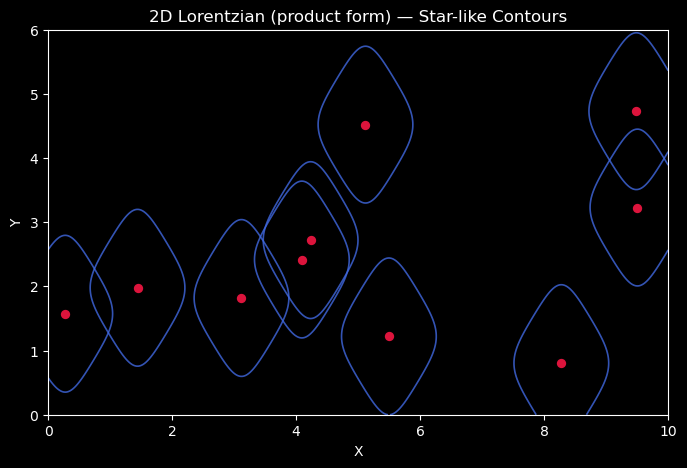

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_points = 10
window = ((0, 10), (0, 6))
rng = np.random.default_rng(1)

# Random points inside window
points = np.column_stack((
    rng.uniform(window[0][0], window[0][1], n_points),
    rng.uniform(window[1][0], window[1][1], n_points)
))

# 2D separable Lorentzian -> star-like contours
def lorentzian_xy(X, Y, x0, y0, gamma_x=0.5, gamma_y=0.5):
    return 1 / ((1 + ((X - x0)**2 / gamma_x**2)) * (1 + ((Y - y0)**2 / gamma_y**2)))

# Grid for evaluation
x = np.linspace(*window[0], 400)
y = np.linspace(*window[1], 400)
X, Y = np.meshgrid(x, y)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(points[:, 0], points[:, 1], color='crimson', s=60, edgecolor='k', zorder=3)

for (x0, y0) in points:
    Z = lorentzian_xy(X, Y, x0, y0, gamma_x=0.5, gamma_y=0.8)
    ax.contour(X, Y, Z, levels=[0.3], colors='royalblue', linewidths=1.2, alpha=0.8)

ax.set_xlim(window[0])
ax.set_ylim(window[1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Lorentzians")
plt.show()


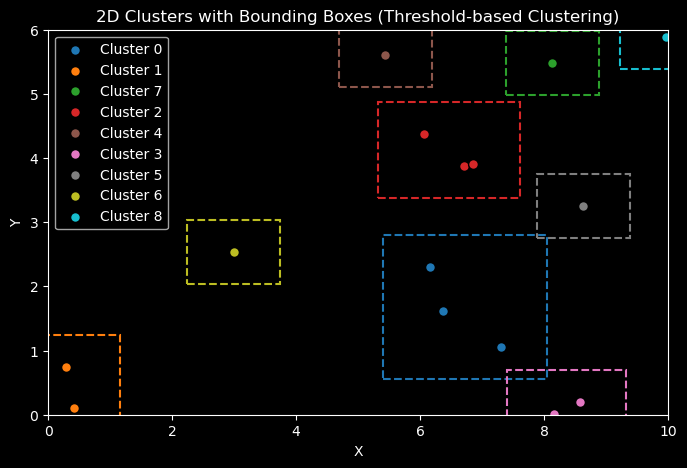

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster

# ---- Your clustering function ----
def find_points_clusters_by_distance(res_locations: list[tuple], 
                            distance_thresholds: dict[str, float], 
                            linkage="single") -> dict[int, list[tuple]]:
    """
    Using scikit-learn to cluster points with component-wise distance thresholds.
    """
    if len(res_locations) == 1:
        return {0: res_locations}
    
    locations = np.array(res_locations)
    thresholds = np.array(list(distance_thresholds.values()))
    scaled_locations = locations / thresholds[np.newaxis, :]
    
    clustering = cluster.AgglomerativeClustering(
        linkage=linkage,
        distance_threshold=1.0,
        n_clusters=None
    )
    labels = clustering.fit_predict(scaled_locations)
    
    groups: dict[int, list] = {}
    for i, label in enumerate(labels):
        groups.setdefault(int(label), []).append(res_locations[i])
    return groups

# ---- Example data ----
rng = np.random.default_rng(0)
res_locations = [tuple(p) for p in rng.uniform([0, 0], [10, 6], size=(15, 2))]
distance_thresholds = {"x": 1.5, "y": 1.0}

# ---- Compute clusters ----
clusters = find_points_clusters_by_distance(res_locations, distance_thresholds)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for (label, points), color in zip(clusters.items(), colors):
    points = np.array(points)
    ax.scatter(points[:, 0], points[:, 1], color=color, label=f"Cluster {label}", s=50, edgecolor='k')
    
    # Draw bounding box (min–max in each dimension)
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    
    # Slightly expand by threshold to indicate area of influence
    dx, dy = distance_thresholds["x"], distance_thresholds["y"]
    rect = plt.Rectangle((xmin - dx/2, ymin - dy/2),
                         (xmax - xmin) + dx,
                         (ymax - ymin) + dy,
                         fill=False, linestyle="--", edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Clusters with Bounding Boxes (Threshold-based Clustering)")
ax.legend()
plt.show()


{2: [(np.float64(5.118216247002567), np.float64(5.702782177955612)), (np.float64(4.851909744316351), np.float64(5.884423198807432))], 4: [(np.float64(1.4415961271963373), np.float64(5.691896682823463)), (np.float64(1.6065200877512686), np.float64(5.819552479296796))], 3: [(np.float64(3.1183145201048545), np.float64(2.539958693835454)), (np.float64(3.03194829291645), np.float64(2.7209873368839093))], 1: [(np.float64(8.277025938204417), np.float64(2.4551948182149674)), (np.float64(7.535131086748066), np.float64(3.228859879315669)), (np.float64(7.503646726300525), np.float64(1.6824525479162395))], 6: [(np.float64(5.495936876730595), np.float64(0.1653546794584102))], 7: [(np.float64(3.297317164990922), np.float64(4.730572220570426))], 0: [(np.float64(1.3404169724716475), np.float64(2.4186779186827754)), (np.float64(2.034552406761496), np.float64(1.573880042651097))], 5: [(np.float64(9.616571936637868), np.float64(4.348739644641202))], 8: [(np.float64(5.412268555474342), np.float64(1.661347

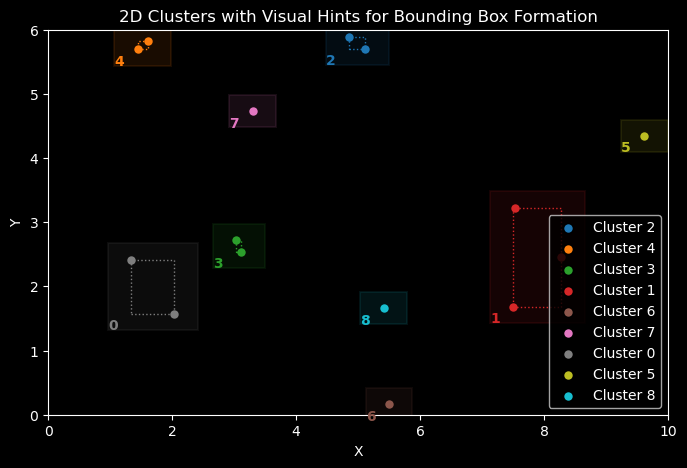

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster

# ---- Your clustering function ----
def find_points_clusters_by_distance(res_locations: list[tuple], 
                            distance_thresholds: dict[str, float], 
                            linkage="single") -> dict[int, list[tuple]]:
    if len(res_locations) == 1:
        return {0: res_locations}
    
    locations = np.array(res_locations)
    thresholds = np.array(list(distance_thresholds.values()))
    scaled_locations = locations / thresholds[np.newaxis, :]
    
    clustering = cluster.AgglomerativeClustering(
        linkage=linkage,
        distance_threshold=1.0,
        n_clusters=None
    )
    labels = clustering.fit_predict(scaled_locations)
    
    groups: dict[int, list] = {}
    for i, label in enumerate(labels):
        groups.setdefault(int(label), []).append(res_locations[i])
    return groups

# ---- Example data ----
rng = np.random.default_rng(1)
res_locations = [tuple(p) for p in rng.uniform([0, 0], [10, 6], size=(15, 2))]
distance_thresholds = {"x": 1.5, "y": 1.0}

# ---- Compute clusters ----
clusters = find_points_clusters_by_distance(res_locations, distance_thresholds)

print(clusters)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for (label, points), color in zip(clusters.items(), colors):
    points = np.array(points)
    ax.scatter(points[:, 0], points[:, 1], color=color, s=50, edgecolor='k', label=f"Cluster {label}")
    
    # Cluster bounds
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    dx, dy = distance_thresholds["x"]/2, distance_thresholds["y"]/2
    
    # Show inner (actual points) and expanded (threshold) boxes
    rect_inner = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               fill=False, linestyle=":", edgecolor=color, linewidth=1)
    rect_outer = plt.Rectangle((xmin - dx/2, ymin - dy/2),
                               (xmax - xmin) + dx, (ymax - ymin) + dy,
                               fill=True, alpha=0.1, facecolor=color, edgecolor=color, linewidth=1.5)
    
    ax.add_patch(rect_outer)
    ax.add_patch(rect_inner)
    
    # Draw lines from cluster points to outer box border (visual hint)
    for (x, y) in points:
        # Connect to nearest side (rough heuristic)
        ax.plot([x, x], [y, np.clip(y, ymin - dy/2, ymax + dy/2)], color=color, alpha=0.3, linewidth=0.8)
        ax.plot([x, np.clip(x, xmin - dx/2, xmax + dx/2)], [y, y], color=color, alpha=0.3, linewidth=0.8)
    
    # Annotate box corners
    ax.text(xmin - dx/2, ymin - dy/2, f"{label}", color=color, fontsize=10, weight='bold')

# Axes and labels
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("2D Clusters with Visual Hints for Bounding Box Formation")
ax.legend()
plt.show()


smth else

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def cluster_by_box_overlap(points, box_halfwidths):
    """
    Cluster points based on overlap of their rectangular boxes.
    
    Args:
        points: list of (x, y)
        box_halfwidths: dict with {'x': dx, 'y': dy}
    
    Returns:
        dict[label] -> list of (x, y)
    """
    dx, dy = box_halfwidths["x"], box_halfwidths["y"]
    n = len(points)
    points = np.array(points)
    
    # Build adjacency matrix based on box overlap
    adjacency = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(i + 1, n):
            # Overlap if projections on both axes overlap
            overlap_x = abs(points[i, 0] - points[j, 0]) <= (dx * 2)
            overlap_y = abs(points[i, 1] - points[j, 1]) <= (dy * 2)
            if overlap_x and overlap_y:
                adjacency[i, j] = adjacency[j, i] = True
    
    # Find connected components (clusters)
    visited = np.zeros(n, dtype=bool)
    clusters = {}
    label = 0
    for i in range(n):
        if not visited[i]:
            # Depth-first search
            stack = [i]
            members = []
            while stack:
                k = stack.pop()
                if visited[k]:
                    continue
                visited[k] = True
                members.append(tuple(points[k]))
                neighbors = np.where(adjacency[k])[0]
                stack.extend(neighbors)
            clusters[label] = members
            label += 1
    
    return clusters


{0: [(np.float64(2.616121342493164), np.float64(1.7909468604847398))], 1: [(np.float64(8.142257405942804), np.float64(0.5514956528105814))], 2: [(np.float64(6.00100525965654), np.float64(4.371363160870768))], 3: [(np.float64(1.8790107336660344), np.float64(0.3308797639984091)), (np.float64(1.0720730845358806), np.float64(0.627261350597649))], 4: [(np.float64(2.749693679060381), np.float64(3.9445980892535557))], 5: [(np.float64(5.62265662780428), np.float64(0.9003735798320167))], 6: [(np.float64(4.3263079080478715), np.float64(4.015783791447122)), (np.float64(4.709098854157575), np.float64(4.16255305321338)), (np.float64(4.227846732701278), np.float64(3.7991063956446984)), (np.float64(3.459606655717331), np.float64(3.0663958414174624))], 7: [(np.float64(9.674359524936767), np.float64(4.098388933857752)), (np.float64(8.912094095005791), np.float64(4.653383654836137))], 8: [(np.float64(3.9162483308002614), np.float64(1.1235154183205884))], 9: [(np.float64(3.1814660061537436), np.float64(5

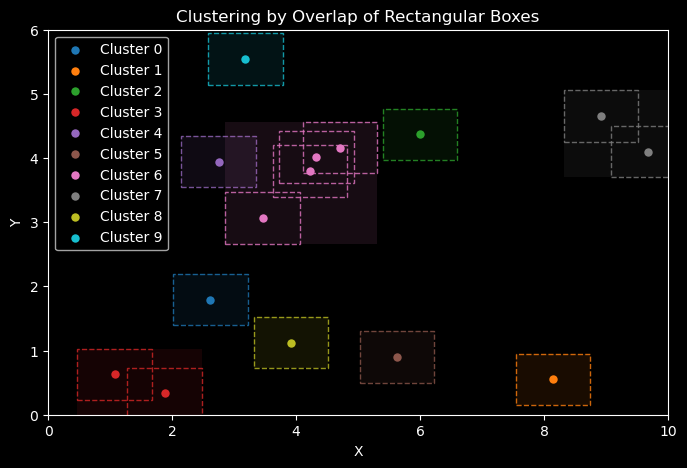

In [19]:
# Example points
rng = np.random.default_rng(2)
points = [tuple(p) for p in rng.uniform([0, 0], [10, 6], size=(15, 2))]
box_halfwidths = {"x": 0.6, "y": 0.4}

# Cluster by box overlap
clusters = cluster_by_box_overlap(points, box_halfwidths)

print(clusters)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for (label, pts), color in zip(clusters.items(), colors):
    pts = np.array(pts)
    ax.scatter(pts[:, 0], pts[:, 1], color=color, edgecolor='k', s=50, label=f"Cluster {label}")
    
    # Draw individual rectangles for each point (their influence area)
    for (x, y) in pts:
        rect = plt.Rectangle((x - box_halfwidths["x"], y - box_halfwidths["y"]),
                             2 * box_halfwidths["x"], 2 * box_halfwidths["y"],
                             fill=False, edgecolor=color, linestyle='--', linewidth=1, alpha=0.8)
        ax.add_patch(rect)
    
    # Draw cluster bounding box (union of all rectangles)
    xmin = min(x - box_halfwidths["x"] for x, y in pts)
    xmax = max(x + box_halfwidths["x"] for x, y in pts)
    ymin = min(y - box_halfwidths["y"] for x, y in pts)
    ymax = max(y + box_halfwidths["y"] for x, y in pts)
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               fill=True, alpha=0.1, facecolor=color, edgecolor='none'))

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Clustering by Overlap of Rectangular Boxes")
ax.legend()
plt.show()


ND points

In [20]:
import numpy as np

def cluster_by_box_overlap_labeled(points, halfwidths):
    """
    Cluster N-dimensional points with labeled axes based on overlap of hyperrectangles.

    Args:
        points: list of dicts, each dict maps axis label -> value
                e.g. [{'x':0,'y':0}, {'x':0.8,'y':0}]
        halfwidths: dict mapping axis label -> half-width
                e.g. {'x':0.5, 'y':0.3}

    Returns:
        dict[label] -> list of points (as dicts)
    """
    n = len(points)
    labels = list(halfwidths.keys())
    
    # Convert points to numpy array in consistent order of labels
    arr = np.array([[p[label] for label in labels] for p in points], dtype=float)
    hw = np.array([halfwidths[label] for label in labels], dtype=float)
    
    # Build adjacency matrix
    adjacency = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(i + 1, n):
            diff = np.abs(arr[i] - arr[j])
            if np.all(diff <= 2 * hw):
                adjacency[i, j] = adjacency[j, i] = True

    # Find connected components
    visited = np.zeros(n, dtype=bool)
    clusters = {}
    label_counter = 0
    for i in range(n):
        if not visited[i]:
            stack = [i]
            members = []
            while stack:
                k = stack.pop()
                if visited[k]:
                    continue
                visited[k] = True
                members.append(points[k])  # keep original dict
                neighbors = np.where(adjacency[k])[0]
                stack.extend(neighbors)
            clusters[label_counter] = members
            label_counter += 1

    return clusters


In [21]:
points = [
    {'x': 0, 'y': 0, 'z': 0},
    {'x': 0.8, 'y': 0, 'z': 0},
    {'x': 3, 'y': 3, 'z': 3},
    {'x': 3.5, 'y': 3, 'z': 3.1}
]

halfwidths = {'x': 0.5, 'y': 0.5, 'z': 0.5}

clusters = cluster_by_box_overlap_labeled(points, halfwidths)
print(clusters)


{0: [{'x': 0, 'y': 0, 'z': 0}, {'x': 0.8, 'y': 0, 'z': 0}], 1: [{'x': 3, 'y': 3, 'z': 3}, {'x': 3.5, 'y': 3, 'z': 3.1}]}


In [ ]:
import numpy as np

def cluster_by_box_overlap_per_point(points, halfwidths_list):
    """
    Cluster N-dimensional points where each point has its own half-widths per axis.

    Args:
        points: list of dicts, each dict maps axis label -> value
        halfwidths_list: list of dicts of the same length as points
                         each dict maps axis label -> half-width for that point

    Returns:
        dict[label] -> list of points (as dicts)
    """
    n = len(points)
    assert n == len(halfwidths_list), "Must provide half-widths for every point"

    labels = list(points[0].keys())  # assume all points share same axis labels

    # Convert to arrays for fast computation
    arr = np.array([[p[label] for label in labels] for p in points], dtype=float)
    hw_arr = np.array([[hw[label] for label in labels] for hw in halfwidths_list], dtype=float)

    # Build adjacency matrix
    adjacency = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(i + 1, n):
            diff = np.abs(arr[i] - arr[j])
            hw_sum = hw_arr[i] + hw_arr[j]  # sum of half-widths per axis
            if np.all(diff <= hw_sum):
                adjacency[i, j] = adjacency[j, i] = True

    # Find connected components (clusters)
    visited = np.zeros(n, dtype=bool)
    clusters = {}
    label_counter = 0
    for i in range(n):
        if not visited[i]:
            stack = [i]
            members = []
            while stack:
                k = stack.pop()
                if visited[k]:
                    continue
                visited[k] = True
                members.append(points[k])
                neighbors = np.where(adjacency[k])[0]
                stack.extend(neighbors)
            clusters[label_counter] = members
            label_counter += 1

    return clusters


----

In [24]:
import numpy as np
from typing import List, Tuple, Dict, Union

def compute_box_adjacency(
    points: List[Dict[str, float]] = None,
    halfwidths_list: List[Dict[str, float]] = None,
    bounds_list: List[List[Tuple[float, float]]] = None
) -> np.ndarray:
    """
    Compute adjacency matrix for N-dimensional rectangular boxes.

    You can provide either:
    1. points + halfwidths_list: each point has its own half-widths
    2. bounds_list: precomputed (min, max) per dimension

    Args:
        points: list of dicts {axis: value}, shape (n_points,)
        halfwidths_list: list of dicts {axis: half-width}, same length as points
        bounds_list: list of list of (min, max) tuples per dimension

    Returns:
        adjacency: n x n boolean matrix
    """
    
    if bounds_list is not None:
        boxes = bounds_list
    elif points is not None and halfwidths_list is not None:
        # Convert points + halfwidths to bounds
        axes = list(points[0].keys())
        boxes = [
            [(p[axis] - hw[axis], p[axis] + hw[axis]) for axis in axes]
            for p, hw in zip(points, halfwidths_list)
        ]
    else:
        raise ValueError("Provide either bounds_list or both points and halfwidths_list")
    
    n = len(boxes)
    adjacency = np.zeros((n, n), dtype=bool)

    for i in range(n):
        for j in range(i + 1, n):
            overlap = True
            for (min_i, max_i), (min_j, max_j) in zip(boxes[i], boxes[j]):
                if max_i < min_j or max_j < min_i:
                    overlap = False
                    break
            if overlap:
                adjacency[i, j] = adjacency[j, i] = True

    return adjacency


In [25]:
points = [{'x':0,'y':0}, {'x':0.8,'y':0}, {'x':3,'y':3}]
halfwidths_list = [{'x':0.5,'y':0.3}, {'x':0.6,'y':0.2}, {'x':0.4,'y':0.4}]

adjacency = compute_box_adjacency(points=points, halfwidths_list=halfwidths_list)
print(adjacency)


[[False  True False]
 [ True False False]
 [False False False]]


In [26]:
bounds_list = [
    [(0,1),(0,1)],
    [(0.8,1.8),(0,0.5)],
    [(3,4),(3,4)]
]

adjacency = compute_box_adjacency(bounds_list=bounds_list)
print(adjacency)


[[False  True False]
 [ True False False]
 [False False False]]
